In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from bayes_opt import BayesianOptimization
from sklearn.preprocessing import label_binarize, MinMaxScaler, StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib import cm


import warnings, json, math, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import norm

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, f1_score, classification_report
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline


In [3]:
df = pd.read_csv("clean_df (1).csv")
df.shape

(2927, 117)

In [4]:
df.isna().sum().sort_values(ascending=False).head(10)


,0
MSZoning_encoded,2270
Lot Frontage,0
Lot Area,0
HouseStyle_MedianPrice,0
MS SubClass,0
Neighborhood_MedianPrice,0
Combo_PriceMean,0
Overall Qual,0
Overall Cond,0
Year Built,0


In [5]:
df.drop('MSZoning_encoded', axis=1, inplace=True)
df.drop('SalePrice', axis=1, inplace=True)

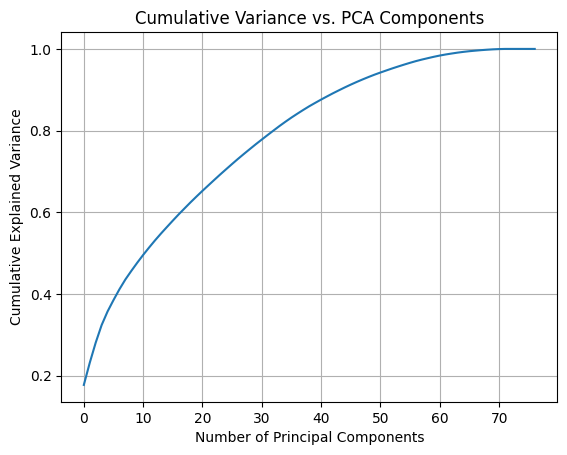

98% variance → 60 components
95% variance → 53 components
90% variance → 45 components
80% variance → 33 components


In [8]:
# Select numeric features (int + float)
scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
X_scaled = scaler.fit_transform(df[numerical_cols])

# Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Plot
plt.plot(cumulative)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance vs. PCA Components")
plt.grid(True)
plt.show()

# Find components for 98%, 95%, 90%, 80%
for target in [0.98, 0.95, 0.90, 0.80]:
    n = np.argmax(cumulative >= target) + 1
    print(f"{target*100:.0f}% variance → {n} components")
# Run PCA
pca = PCA()

In [9]:
targets = [0.80, 0.90, 0.95, 0.98]
reduced_datasets = {}

for target in targets:
    n = np.argmax(cumulative >= target) + 1
    pca = PCA(n_components=n)
    X_reduced = pca.fit_transform(X_scaled)
    reduced_datasets[target] = X_reduced
    print(f'Variance {target*100:.0f}% → {n} components → shape {X_reduced.shape}')

Variance 80% → 33 components → shape (2927, 33)
Variance 90% → 45 components → shape (2927, 45)
Variance 95% → 53 components → shape (2927, 53)
Variance 98% → 60 components → shape (2927, 60)


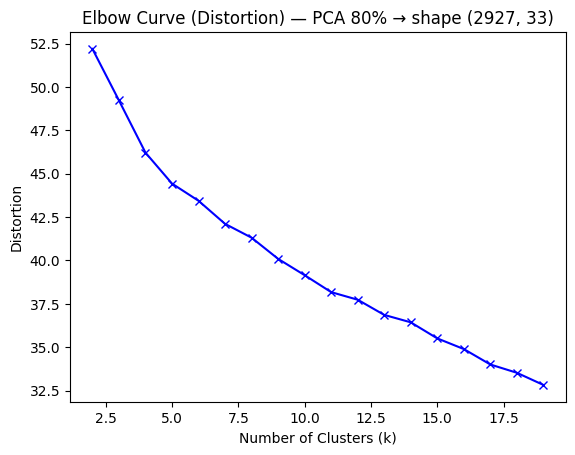

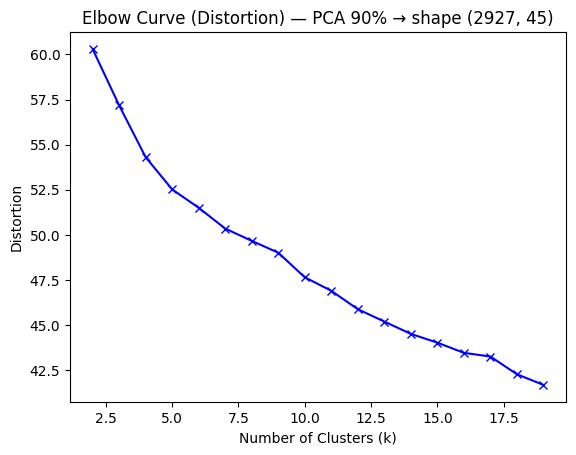

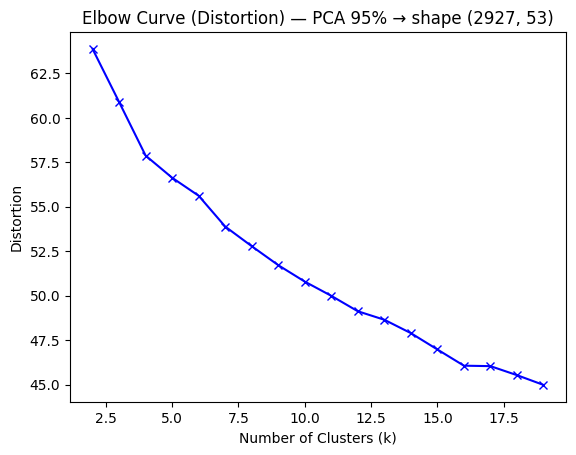

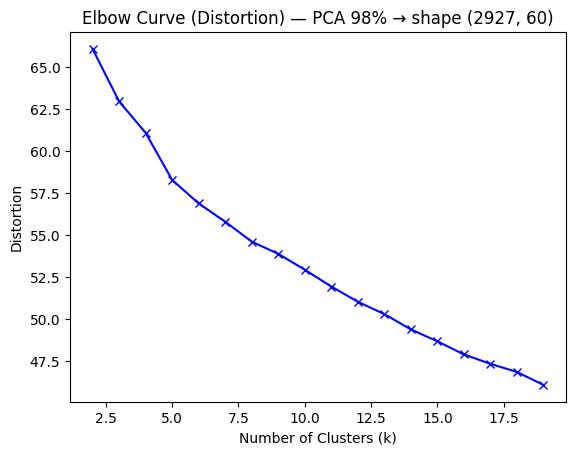


TOP 5 DISTORTION DROPS PER PCA VARIANCE

PCA 80% variance:
  k=3 → k=4 | 6.11% drop
  k=2 → k=3 | 5.69% drop
  k=4 → k=5 | 3.86% drop
  k=6 → k=7 | 3.06% drop
  k=8 → k=9 | 2.95% drop

PCA 90% variance:
  k=2 → k=3 | 5.18% drop
  k=3 → k=4 | 5.02% drop
  k=4 → k=5 | 3.29% drop
  k=9 → k=10 | 2.78% drop
  k=17 → k=18 | 2.27% drop

PCA 95% variance:
  k=3 → k=4 | 4.95% drop
  k=2 → k=3 | 4.67% drop
  k=6 → k=7 | 3.11% drop
  k=4 → k=5 | 2.15% drop
  k=7 → k=8 | 2.05% drop

PCA 98% variance:
  k=2 → k=3 | 4.73% drop
  k=4 → k=5 | 4.59% drop
  k=3 → k=4 | 2.97% drop
  k=5 → k=6 | 2.39% drop
  k=7 → k=8 | 2.12% drop


In [10]:
# dictionary to store percent drops per PCA dataset
percent_drops_per_target = {}

for target, X_reduced in reduced_datasets.items():
    distortions = []
    K = range(2, 20)

    # compute distortions
    for k in K:
        model = KMeans(n_clusters=k, random_state=42).fit(X_reduced)
        dist = np.min(cdist(X_reduced, model.cluster_centers_, 'euclidean'), axis=1)
        distortions.append(np.mean(dist**2))

    # percent decreases for this dataset
    percent_decreases = []
    for i in range(1, len(distortions)):
        old = distortions[i-1]
        new = distortions[i]
        percent = (old - new) / old * 100
        percent_decreases.append((K[i-1], K[i], percent))  # (k_old, k_new, percent)

    percent_drops_per_target[target] = percent_decreases

    # plot elbow
    plt.plot(K, distortions, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Distortion')
    plt.title(f'Elbow Curve (Distortion) — PCA {target*100:.0f}% → shape {X_reduced.shape}')
    plt.show()

print("\nTOP 5 DISTORTION DROPS PER PCA VARIANCE")

for target, drops in percent_drops_per_target.items():
    print(f"\nPCA {target*100:.0f}% variance:")

    best5 = sorted(drops, key=lambda x: x[2], reverse=True)[:5]

    for (k_old, k_new, percent) in best5:
        print(f"  k={k_old} → k={k_new} | {percent:.2f}% drop")


In [11]:
def plot_full_silhouette(X, labels, k, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    silhouette_vals = silhouette_samples(X, labels)
    silhouette_avg = np.mean(silhouette_vals)

    y_lower = 10
    for i in range(k):
        ith_vals = silhouette_vals[labels == i]
        ith_vals.sort()
        size = ith_vals.shape[0]
        y_upper = y_lower + size

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, ith_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)

        ax.text(-0.05, y_lower + size / 2.0, str(i), fontsize=8)
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Silhouette value")
    ax.set_ylabel("Cluster")
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()


In [12]:
def plot_pca_scatter(X_reduced, labels, centers, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap="tab10", s=25)
    plt.scatter(centers[:, 0], centers[:, 1],
                c="black", marker="x", s=120, label="Centers")
    plt.title(title)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


Here we have the scater plot of the main 2 PCA's with clustering based on the nr of clusters taken form the elbow method(eye test)

In [14]:
# TODO

The clusters resulting from these have messy margins and do not look right

In [15]:
# TODO

The values found for k are the same with the ones found with the elbow method but for comparison of the 2 we will plot the main 2 PCA's of the clustering with some local maximums of the sil scores.

In [16]:
# TODO

TODO: Interpretation

In [17]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

In [18]:
loading_df = pd.DataFrame(
    loadings[:, :2],  # first 2 PCs
    columns=["PC1", "PC2"],
    index=numerical_cols
)


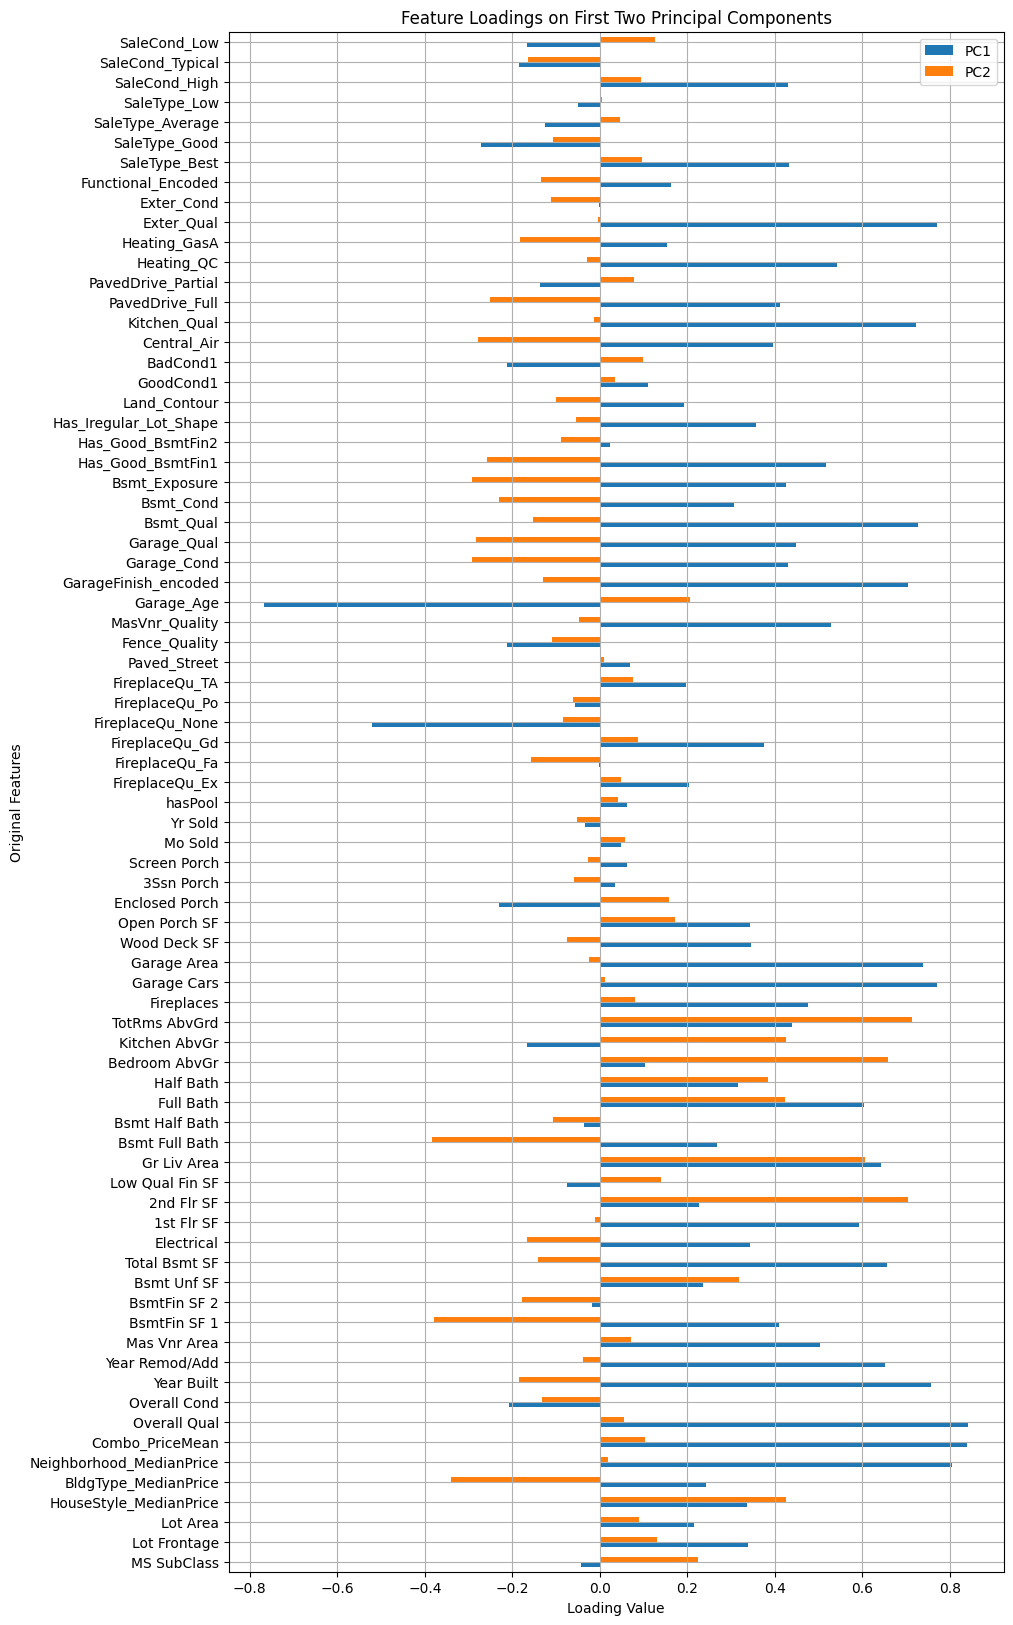

In [19]:
loading_df.plot(kind='barh', figsize=(10, 20))
plt.title("Feature Loadings on First Two Principal Components")
plt.xlabel("Loading Value")      # now X-axis shows loadings
plt.ylabel("Original Features")  # Y-axis shows feature names
plt.grid(True)
plt.show()


TODO: Interpretation

Now use a logarithmic transformation before the StandardScaler

In [34]:
# reread df
df = pd.read_csv("clean_df (1).csv")
df.drop('MSZoning_encoded', axis=1, inplace=True)
df.drop('SalePrice', axis=1, inplace=True)

In [35]:
log_transformer = FunctionTransformer(np.log1p)
scaler = StandardScaler()

In [36]:
log_numerical_cols = log_transformer.fit_transform(df[numerical_cols])

X_scaled_log = scaler.fit_transform(log_numerical_cols)
df_scaled_log = pd.DataFrame(X_scaled_log, columns=numerical_cols)
df_scaled_log.shape

(2927, 77)

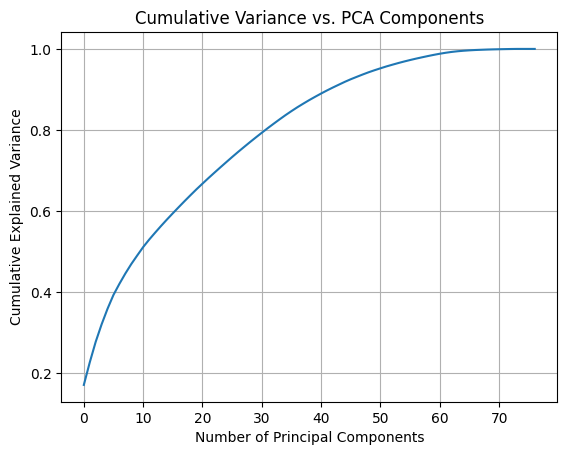

98% variance → 59 components
95% variance → 51 components
90% variance → 43 components
80% variance → 32 components


In [37]:
pca = PCA()
df_log_pca = pca.fit_transform(df_scaled_log)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Plot
plt.plot(cumulative)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance vs. PCA Components")
plt.grid(True)
plt.show()

# Find components for 98%, 95%, 90%, 80%
for target in [0.98, 0.95, 0.90, 0.80]:
    n = np.argmax(cumulative >= target) + 1
    print(f"{target*100:.0f}% variance → {n} components")
# Run PCA
pca = PCA()

In [38]:
targets = [0.80, 0.90, 0.95, 0.98]
reduced_datasets = {}

for target in targets:
    n = np.argmax(cumulative >= target) + 1
    pca = PCA(n_components=n)
    X_logged_reduced = pca.fit_transform(df_scaled_log)
    reduced_datasets[target] = X_logged_reduced
    print(f'Variance {target*100:.0f}% → {n} components → shape {X_logged_reduced.shape}')

Variance 80% → 32 components → shape (2927, 32)
Variance 90% → 43 components → shape (2927, 43)
Variance 95% → 51 components → shape (2927, 51)
Variance 98% → 59 components → shape (2927, 59)


Now kmeans for logged and pca reduced df

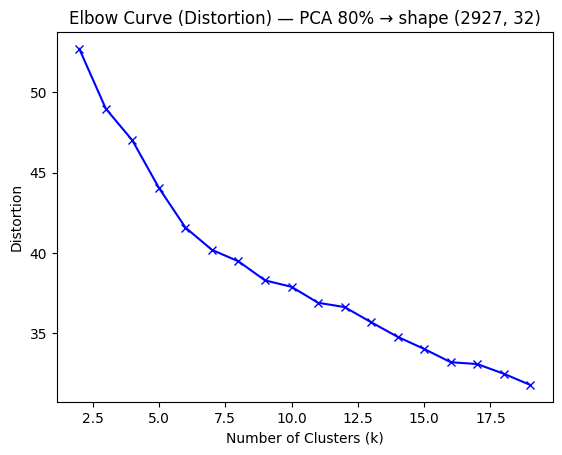

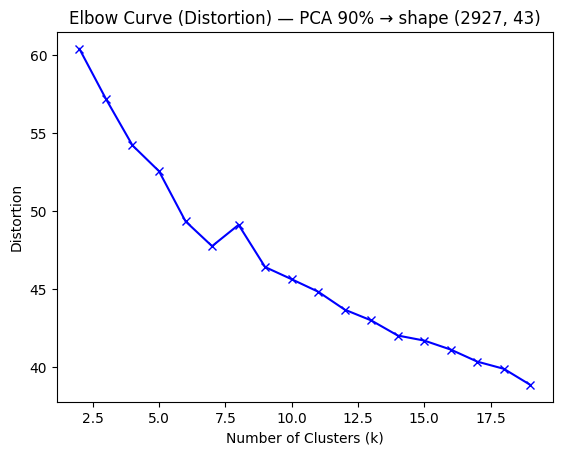

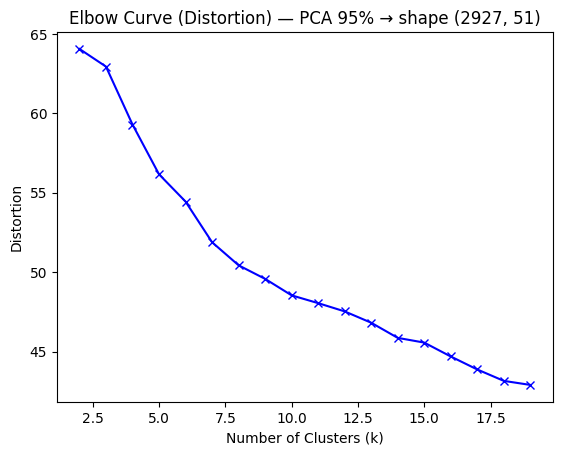

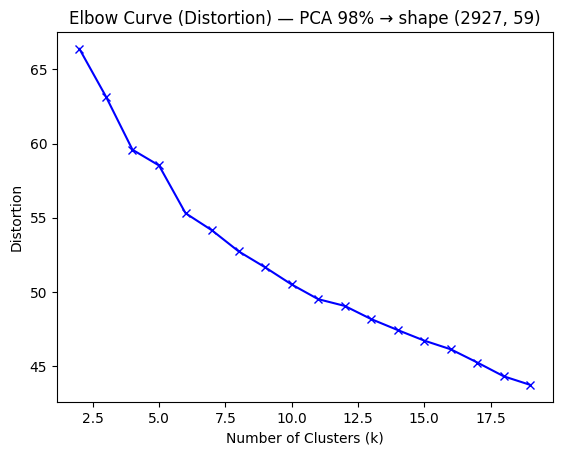


TOP 5 DISTORTION DROPS PER PCA VARIANCE

PCA 80% variance:
  k=2 → k=3 | 7.06% drop
  k=4 → k=5 | 6.28% drop
  k=5 → k=6 | 5.60% drop
  k=3 → k=4 | 4.02% drop
  k=6 → k=7 | 3.34% drop

PCA 90% variance:
  k=5 → k=6 | 6.11% drop
  k=8 → k=9 | 5.51% drop
  k=2 → k=3 | 5.31% drop
  k=3 → k=4 | 5.20% drop
  k=6 → k=7 | 3.22% drop

PCA 95% variance:
  k=3 → k=4 | 5.79% drop
  k=4 → k=5 | 5.29% drop
  k=6 → k=7 | 4.70% drop
  k=5 → k=6 | 3.06% drop
  k=7 → k=8 | 2.80% drop

PCA 98% variance:
  k=3 → k=4 | 5.67% drop
  k=5 → k=6 | 5.50% drop
  k=2 → k=3 | 4.84% drop
  k=7 → k=8 | 2.60% drop
  k=9 → k=10 | 2.24% drop


In [39]:
# dictionary to store percent drops per PCA dataset
percent_drops_per_target = {}

for target, X_logged_reduced in reduced_datasets.items():
    distortions = []
    K = range(2, 20)

    # compute distortions
    for k in K:
        model = KMeans(n_clusters=k, random_state=42).fit(X_logged_reduced)
        dist = np.min(cdist(X_logged_reduced, model.cluster_centers_, 'euclidean'), axis=1)
        distortions.append(np.mean(dist**2))

    # percent decreases for this dataset
    percent_decreases = []
    for i in range(1, len(distortions)):
        old = distortions[i-1]
        new = distortions[i]
        percent = (old - new) / old * 100
        percent_decreases.append((K[i-1], K[i], percent))  # (k_old, k_new, percent)

    percent_drops_per_target[target] = percent_decreases

    # plot elbow
    plt.plot(K, distortions, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Distortion')
    plt.title(f'Elbow Curve (Distortion) — PCA {target*100:.0f}% → shape {X_logged_reduced.shape}')
    plt.show()

print("\nTOP 5 DISTORTION DROPS PER PCA VARIANCE")

for target, drops in percent_drops_per_target.items():
    print(f"\nPCA {target*100:.0f}% variance:")

    best5 = sorted(drops, key=lambda x: x[2], reverse=True)[:5]

    for (k_old, k_new, percent) in best5:
        print(f"  k={k_old} → k={k_new} | {percent:.2f}% drop")


Silhouette plots

In [40]:
def plot_full_silhouette(X, labels, k, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    silhouette_vals = silhouette_samples(X, labels)
    silhouette_avg = np.mean(silhouette_vals)

    y_lower = 10
    for i in range(k):
        ith_vals = silhouette_vals[labels == i]
        ith_vals.sort()
        size = ith_vals.shape[0]
        y_upper = y_lower + size

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, ith_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)

        ax.text(-0.05, y_lower + size / 2.0, str(i), fontsize=8)
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Silhouette value")
    ax.set_ylabel("Cluster")
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()


In [41]:
def plot_pca_scatter(X_logged_reduced, labels, centers, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(X_logged_reduced[:, 0], X_logged_reduced[:, 1], c=labels, cmap="tab10", s=25)
    plt.scatter(centers[:, 0], centers[:, 1],
                c="black", marker="x", s=120, label="Centers")
    plt.title(title)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


Here we have the scater plot of the main 2 PCA's with clustering based on the nr of clusters taken form the elbow method(eye test)

In [42]:
# TODO

The clusters resulting from these have messy margins and do not look right


=== PCA 80% Variance — 32 components ===


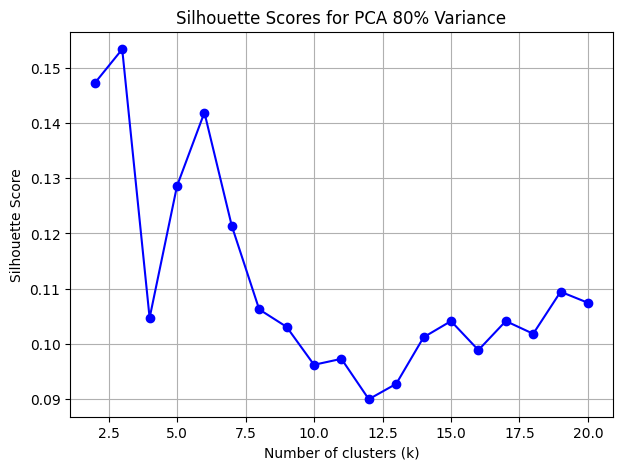

Best k according to silhouette score = 3 (score = 0.1534)

=== PCA 90% Variance — 43 components ===


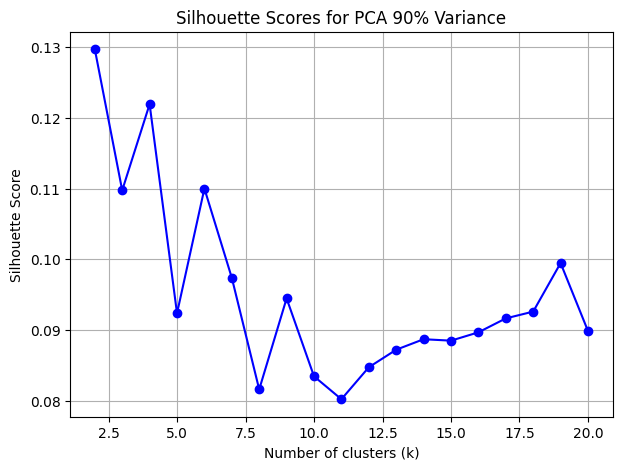

Best k according to silhouette score = 2 (score = 0.1297)

=== PCA 95% Variance — 51 components ===


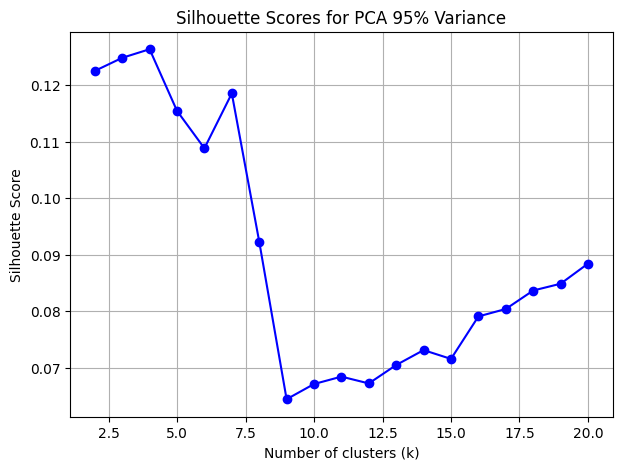

Best k according to silhouette score = 4 (score = 0.1264)

=== PCA 98% Variance — 59 components ===


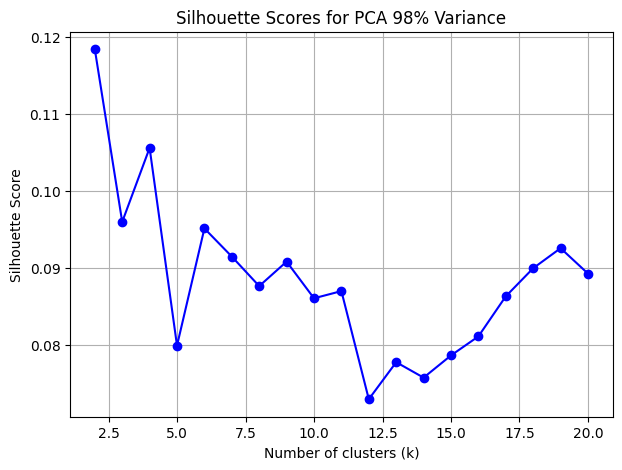

Best k according to silhouette score = 2 (score = 0.1184)


In [43]:
best_k_for_each = {}

for target, X_logged_reduced in reduced_datasets.items():
    print(f"\n=== PCA {target*100:.0f}% Variance — {X_logged_reduced.shape[1]} components ===")

    k_range = range(2, 21)
    sil_scores = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42).fit(X_logged_reduced)
        labels = kmeans.labels_
        sil = silhouette_score(X_logged_reduced, labels)
        sil_scores.append(sil)

    plt.figure(figsize=(7, 5))
    plt.plot(k_range, sil_scores, "bo-")
    plt.title(f"Silhouette Scores for PCA {target*100:.0f}% Variance")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

    best_index = np.argmax(sil_scores)
    best_k = k_range[best_index]

    best_k_for_each[target] = best_k
    print(f"Best k according to silhouette score = {best_k} (score = {sil_scores[best_index]:.4f})")

The values found for k are the same with the ones found with the elbow method but for comparison of the 2 we will plot the main 2 PCA's of the clustering with some local maximums of the sil scores.

In [44]:
# TODO

Now onto the loadings for the logged df

In [45]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

In [46]:
loading_df = pd.DataFrame(
    loadings[:, :2],  # first 2 PCs
    columns=["PC1", "PC2"],
    index=numerical_cols
)


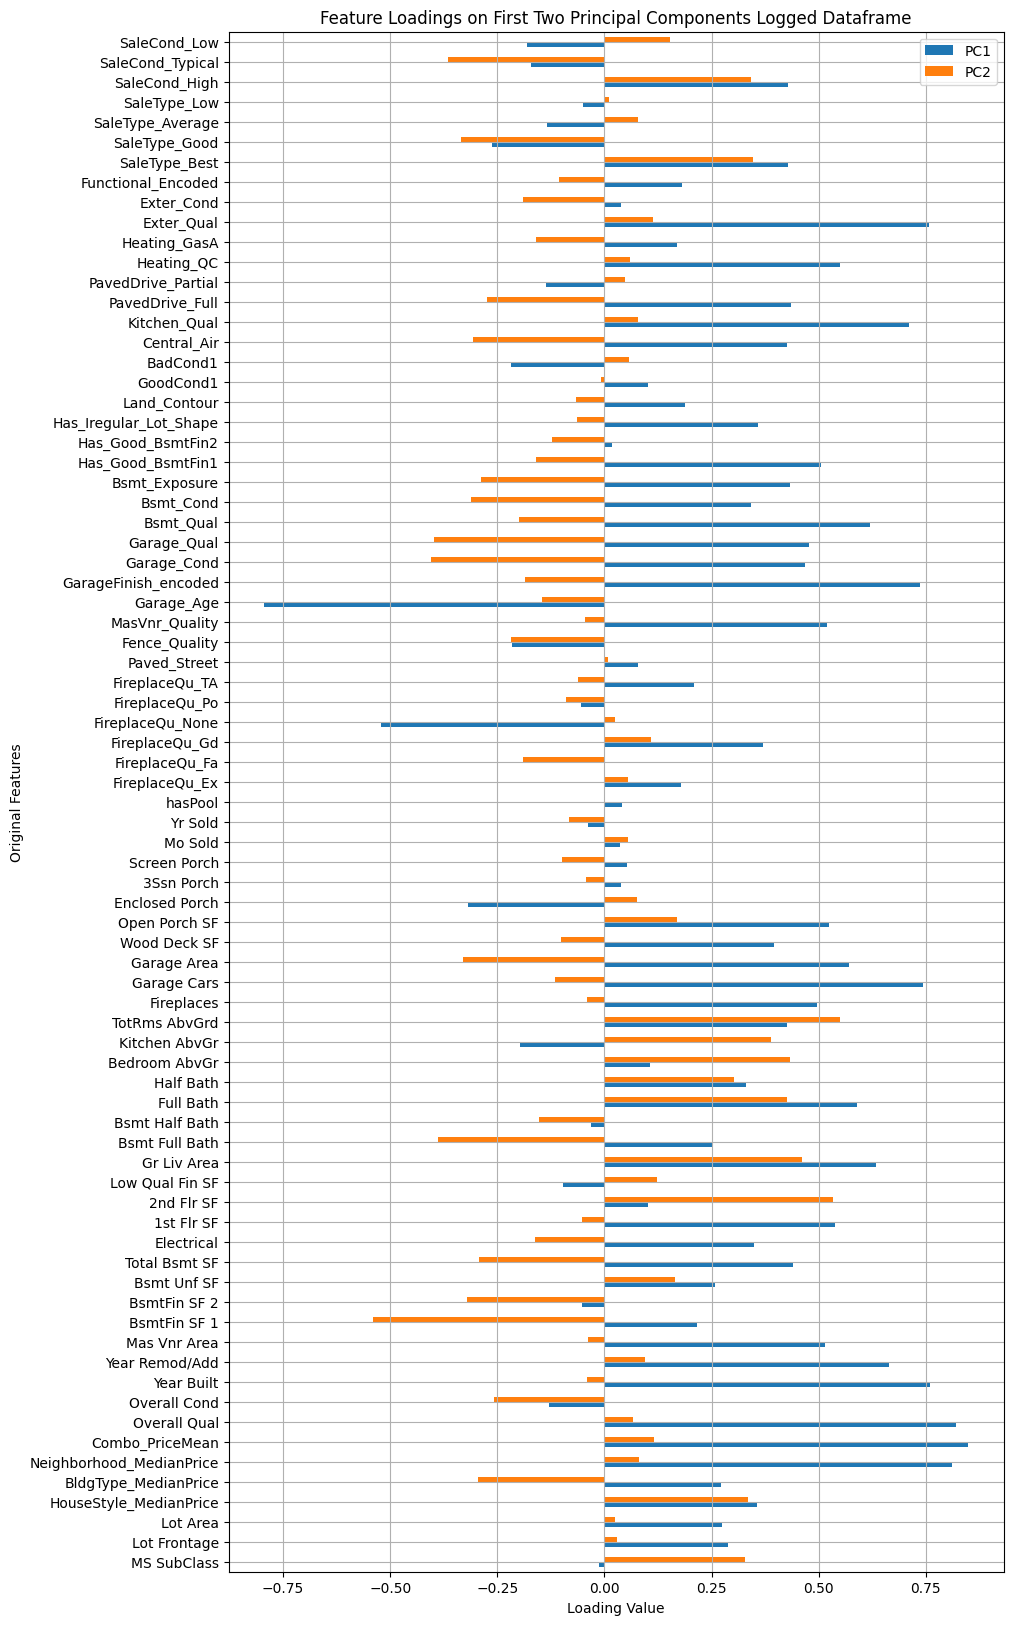

In [47]:
loading_df.plot(kind='barh', figsize=(10, 20))
plt.title("Feature Loadings on First Two Principal Components Logged Dataframe")
plt.xlabel("Loading Value")      # now X-axis shows loadings
plt.ylabel("Original Features")  # Y-axis shows feature names
plt.grid(True)
plt.show()
